# Transformers as Feature Extractors for Text Classification

**Learning Objectives:**
- Understand what transformers as feature extractors are and when to use them
- Load and use a pre-trained DistilBERT model without fine-tuning
- Extract meaningful text embeddings (features) from transformer models
- Train classical ML classifiers on top of transformer features
- Evaluate and analyze classification results

**What You'll Build:**
A sentiment classifier for IMDB movie reviews using DistilBERT embeddings + Logistic Regression

**Estimated Runtime:** ~2-5 minutes on Apple Silicon (MPS), ~15-20 minutes on CPU

## 1. Introduction & Concepts

### What are Transformers as Feature Extractors?

Instead of training a transformer from scratch or fine-tuning it for our task, we can use a **pre-trained transformer model as a feature extractor**:

1. **Take a pre-trained model** (e.g., BERT, DistilBERT) that already understands language
2. **Freeze its parameters** - don't update the model weights
3. **Pass text through it** to get rich numerical representations (embeddings)
4. **Train a simple classifier** (like Logistic Regression) on these embeddings

### The Pipeline

```
Text → Tokenizer → Frozen Transformer → Hidden States → Pooling → Feature Vector → Classifier → Prediction
"Great movie!" → [101, 2307, ...] → DistilBERT → [768-dim vectors] → [768-dim] → LogReg → Positive
```

### Feature Extraction vs Fine-Tuning

| Aspect | Feature Extraction | Fine-Tuning |
|--------|-------------------|-------------|
| **Model Parameters** | Frozen (no update) | Updated during training |
| **Training Speed** | Fast (only train classifier) | Slow (update entire model) |
| **Compute Required** | Low (CPU/small GPU) | High (GPU required) |
| **Data Required** | Works with small datasets | Needs more data |
| **Performance** | Good (not task-optimized) | Better (task-specific) |
| **Use Case** | Quick experiments, limited resources | Production systems, max performance |

### When to Use Feature Extraction?

✅ **Use feature extraction when:**
- You have a small dataset (few hundred to few thousand samples)
- You have limited compute resources
- You need quick results for experimentation
- The pre-trained model is already good at understanding your domain
- You want to try multiple classifiers quickly

❌ **Consider fine-tuning when:**
- You have a large dataset (10k+ samples)
- You have GPU resources and time
- You need maximum performance
- Your task is very different from pre-training tasks

### Why DistilBERT?

DistilBERT is a "distilled" (smaller, faster) version of BERT:
- **60% faster** than BERT
- **40% smaller** (6 layers vs 12)
- **Retains 97%** of BERT's performance
- **768-dimensional** embeddings (same as BERT)
- Perfect for learning and resource-constrained environments

## 2. Environment Setup & Device Detection

Let's import required libraries and detect the best available device (MPS GPU, CUDA GPU, or CPU).

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn

# HuggingFace libraries
from transformers import AutoModel, AutoTokenizer
from datasets import load_dataset

# Scikit-learn for classical ML
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)
from sklearn.decomposition import PCA

# For reproducibility
import random

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device detection
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✓ Using CUDA GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("✓ Using Apple Silicon GPU (MPS)")
    print("  → Your M4 Max with 40-core GPU will significantly speed up feature extraction!")
else:
    device = torch.device('cpu')
    print("⚠ Using CPU (slower, but will work)")

print(f"\nDevice: {device}")
print(f"PyTorch version: {torch.__version__}")

✓ Using Apple Silicon GPU (MPS)
  → Your M4 Max with 40-core GPU will significantly speed up feature extraction!

Device: mps
PyTorch version: 2.5.1


## 3. IMDB Dataset Loading & Exploration

We'll use the IMDB movie reviews dataset for binary sentiment classification:
- **Task:** Predict if a review is positive or negative
- **Classes:** 0 (negative), 1 (positive)
- **Original size:** 25,000 train, 25,000 test
- **We'll use a subset** for faster experimentation and learning

In [3]:
# Load IMDB dataset from HuggingFace
print("Loading IMDB dataset...")
dataset = load_dataset("imdb")

print(f"\n✓ Dataset loaded successfully!")
print(f"\nDataset structure:")
print(dataset)

print(f"\nTrain set: {len(dataset['train'])} samples")
print(f"Test set: {len(dataset['test'])} samples")

Loading IMDB dataset...

✓ Dataset loaded successfully!

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Train set: 25000 samples
Test set: 25000 samples


In [4]:
# Let's look at a few examples
print("Sample reviews from the dataset:\n")
print("="*80)

for i in range(2):
    sample = dataset['train'][i]
    label = "POSITIVE" if sample['label'] == 1 else "NEGATIVE"
    text = sample['text'][:200] + "..."  # Show first 200 chars
    print(f"Review {i+1} [{label}]:")
    print(f"{text}")
    print("="*80)

Sample reviews from the dataset:

Review 1 [NEGATIVE]:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...
Review 2 [NEGATIVE]:
"I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that ...


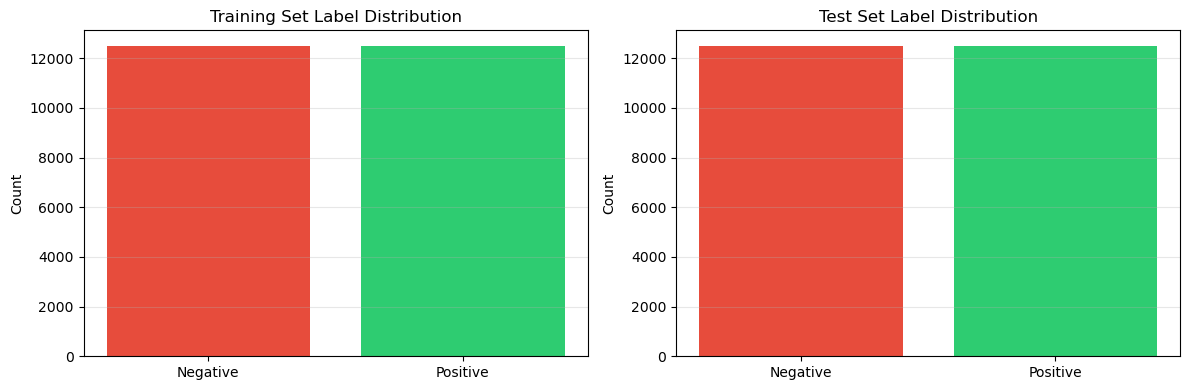


✓ Dataset is balanced (50% positive, 50% negative)


In [5]:
# Visualize label distribution
train_labels = [sample['label'] for sample in dataset['train']]
test_labels = [sample['label'] for sample in dataset['test']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train set distribution
axes[0].bar(['Negative', 'Positive'], 
            [train_labels.count(0), train_labels.count(1)],
            color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Training Set Label Distribution')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Test set distribution
axes[1].bar(['Negative', 'Positive'], 
            [test_labels.count(0), test_labels.count(1)],
            color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Test Set Label Distribution')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Dataset is balanced (50% positive, 50% negative)")

In [6]:
# Create a manageable subset for faster experimentation
# You can increase these numbers if you want better performance
TRAIN_SIZE = 5000  # Use 5000 training samples
TEST_SIZE = 1000   # Use 1000 test samples

# Randomly sample from the dataset
train_dataset = dataset['train'].shuffle(seed=SEED).select(range(TRAIN_SIZE))
test_dataset = dataset['test'].shuffle(seed=SEED).select(range(TEST_SIZE))

print(f"✓ Created subset:")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Test samples: {len(test_dataset)}")
print(f"\nNote: Using a subset for faster learning. For better performance, increase TRAIN_SIZE and TEST_SIZE.")

✓ Created subset:
  Training samples: 5000
  Test samples: 1000

Note: Using a subset for faster learning. For better performance, increase TRAIN_SIZE and TEST_SIZE.


## 4. Load Pre-trained DistilBERT

### Understanding the Model

We'll load `distilbert-base-uncased` which:
- Was trained on English Wikipedia and BookCorpus
- Understands language semantics, grammar, and context
- Has 66 million parameters
- Produces 768-dimensional embeddings

### Why AutoModel instead of AutoModelForSequenceClassification?

- `AutoModel`: Base model without a classification head (what we want!)
- `AutoModelForSequenceClassification`: Includes a classification layer (for fine-tuning)

We want the base model because we'll use scikit-learn classifiers instead.

In [7]:
# Model checkpoint
MODEL_NAME = "distilbert-base-uncased"

print(f"Loading {MODEL_NAME}...")
print("This may take a minute on first run (downloading ~250MB)\n")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load model
model = AutoModel.from_pretrained(MODEL_NAME)

print(f"✓ Model and tokenizer loaded successfully!")
print(f"\nModel architecture:")
print(f"  - Layers: 6 transformer blocks")
print(f"  - Hidden size: 768 dimensions")
print(f"  - Attention heads: 12 per layer")
print(f"  - Parameters: {model.num_parameters():,}")

Loading distilbert-base-uncased...
This may take a minute on first run (downloading ~250MB)



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

✓ Model and tokenizer loaded successfully!

Model architecture:
  - Layers: 6 transformer blocks
  - Hidden size: 768 dimensions
  - Attention heads: 12 per layer
  - Parameters: 66,362,880


In [8]:
# Move model to device (MPS/CUDA/CPU)
model = model.to(device)

# IMPORTANT: Freeze all parameters
# We're using the model as a feature extractor, not training it
for param in model.parameters():
    param.requires_grad = False

# Set to evaluation mode (disables dropout, etc.)
model.eval()

print("✓ Model moved to device and parameters frozen")
print(f"  Device: {device}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
print(f"  Frozen parameters: {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}")
print(f"\n→ We won't update any model weights - just use them as-is for feature extraction!")

✓ Model moved to device and parameters frozen
  Device: mps
  Trainable parameters: 0
  Frozen parameters: 66,362,880

→ We won't update any model weights - just use them as-is for feature extraction!


In [9]:
# Let's test the tokenizer on an example
test_text = "This movie was absolutely fantastic! I loved every minute of it."

# Tokenize
tokens = tokenizer(test_text, return_tensors="pt", padding=True, truncation=True)

print(f"Example text: {test_text}\n")
print(f"Tokenized output:")
print(f"  Input IDs shape: {tokens['input_ids'].shape}")
print(f"  Input IDs: {tokens['input_ids'][0][:20]}...")
print(f"  Attention mask shape: {tokens['attention_mask'].shape}")
print(f"\nDecoded tokens:")
decoded_tokens = [tokenizer.decode([token_id]) for token_id in tokens['input_ids'][0][:20]]
print(f"  {decoded_tokens}")

Example text: This movie was absolutely fantastic! I loved every minute of it.

Tokenized output:
  Input IDs shape: torch.Size([1, 15])
  Input IDs: tensor([  101,  2023,  3185,  2001,  7078, 10392,   999,  1045,  3866,  2296,
         3371,  1997,  2009,  1012,   102])...
  Attention mask shape: torch.Size([1, 15])

Decoded tokens:
  ['[CLS]', 'this', 'movie', 'was', 'absolutely', 'fantastic', '!', 'i', 'loved', 'every', 'minute', 'of', 'it', '.', '[SEP]']


## 5. Feature Extraction Pipeline

### The Process

1. **Tokenize** text into input IDs
2. **Forward pass** through DistilBERT
3. **Extract last hidden state** (output from final layer)
4. **Pool** the sequence of embeddings into a single vector
5. **Create feature matrix** for all samples

### Pooling Strategies

The model outputs one 768-dim vector per token. We need one vector per review. How?

1. **CLS token pooling**: Use the [CLS] token embedding (first token)
   - BERT was trained to make [CLS] represent the whole sequence
   - Most common approach
   
2. **Mean pooling**: Average all token embeddings
   - Uses information from all tokens
   - Often works better for semantic similarity
   
3. **Max pooling**: Take maximum values across tokens
   - Captures salient features
   - Less common

We'll use **mean pooling** with attention mask weighting (ignore padding tokens).

In [10]:
def mean_pooling(model_output, attention_mask):
    """
    Perform mean pooling on token embeddings, considering attention mask.
    
    Args:
        model_output: Output from the model (contains last_hidden_state)
        attention_mask: Attention mask (1 for real tokens, 0 for padding)
    
    Returns:
        Pooled embeddings of shape (batch_size, hidden_size)
    """
    # Extract token embeddings (last hidden state)
    token_embeddings = model_output.last_hidden_state  # Shape: (batch_size, seq_len, hidden_size)
    
    # Expand attention mask to match token embeddings dimensions
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    
    # Sum embeddings (ignoring padding tokens)
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
    
    # Sum attention mask to get count of real tokens
    sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
    
    # Calculate mean
    mean_embeddings = sum_embeddings / sum_mask
    
    return mean_embeddings

print("✓ Mean pooling function defined")

✓ Mean pooling function defined


In [11]:
# Test feature extraction on a single example
test_text = "This movie was absolutely fantastic!"

# Tokenize
inputs = tokenizer(test_text, return_tensors="pt", padding=True, truncation=True, max_length=512)
inputs = {k: v.to(device) for k, v in inputs.items()}  # Move to device

# Extract features (no gradient computation needed)
with torch.no_grad():
    outputs = model(**inputs)
    embeddings = mean_pooling(outputs, inputs['attention_mask'])

# Move back to CPU for inspection
embeddings_cpu = embeddings.cpu()

print(f"Test text: {test_text}\n")
print(f"Feature extraction results:")
print(f"  Input shape: {inputs['input_ids'].shape}")
print(f"  Last hidden state shape: {outputs.last_hidden_state.shape}")
print(f"  Pooled embedding shape: {embeddings_cpu.shape}")
print(f"\n✓ Successfully extracted 768-dimensional feature vector!")
print(f"\nFirst 10 values of embedding: {embeddings_cpu[0][:10].numpy()}")

Test text: This movie was absolutely fantastic!

Feature extraction results:
  Input shape: torch.Size([1, 8])
  Last hidden state shape: torch.Size([1, 8, 768])
  Pooled embedding shape: torch.Size([1, 768])

✓ Successfully extracted 768-dimensional feature vector!

First 10 values of embedding: [ 0.35666078 -0.19835906  0.13336378  0.05098109  0.2304713  -0.3612459
  0.1985746   0.8320927  -0.2281445   0.13320027]


In [12]:
def extract_features(dataset, batch_size=32):
    """
    Extract features from all samples in a dataset.
    
    Args:
        dataset: HuggingFace dataset
        batch_size: Number of samples to process at once
    
    Returns:
        features: numpy array of shape (num_samples, 768)
        labels: numpy array of shape (num_samples,)
    """
    all_embeddings = []
    all_labels = []
    
    # Process in batches
    for i in tqdm(range(0, len(dataset), batch_size), desc="Extracting features"):
        # Get batch
        batch = dataset[i:i+batch_size]
        texts = batch['text']
        labels = batch['label']
        
        # Tokenize batch
        inputs = tokenizer(
            texts, 
            padding=True, 
            truncation=True, 
            max_length=512,
            return_tensors="pt"
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Extract features
        with torch.no_grad():
            outputs = model(**inputs)
            embeddings = mean_pooling(outputs, inputs['attention_mask'])
        
        # Move to CPU and store
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.extend(labels)
    
    # Concatenate all batches
    features = np.vstack(all_embeddings)
    labels = np.array(all_labels)
    
    return features, labels

print("✓ Feature extraction function defined")

✓ Feature extraction function defined


In [13]:
# Extract features for training and test sets
print("Extracting features from training set...")
X_train, y_train = extract_features(train_dataset, batch_size=32)

print("\nExtracting features from test set...")
X_test, y_test = extract_features(test_dataset, batch_size=32)

print(f"\n✓ Feature extraction complete!")
print(f"\nTraining set:")
print(f"  Features shape: {X_train.shape}")
print(f"  Labels shape: {y_train.shape}")
print(f"\nTest set:")
print(f"  Features shape: {X_test.shape}")
print(f"  Labels shape: {y_test.shape}")
print(f"\n→ Each review is now represented as a 768-dimensional vector!")

Extracting features from training set...


Extracting features:   0%|          | 0/157 [00:00<?, ?it/s]


Extracting features from test set...


Extracting features:   0%|          | 0/32 [00:00<?, ?it/s]


✓ Feature extraction complete!

Training set:
  Features shape: (5000, 768)
  Labels shape: (5000,)

Test set:
  Features shape: (1000, 768)
  Labels shape: (1000,)

→ Each review is now represented as a 768-dimensional vector!


Reducing dimensions for visualization (768D → 2D)...


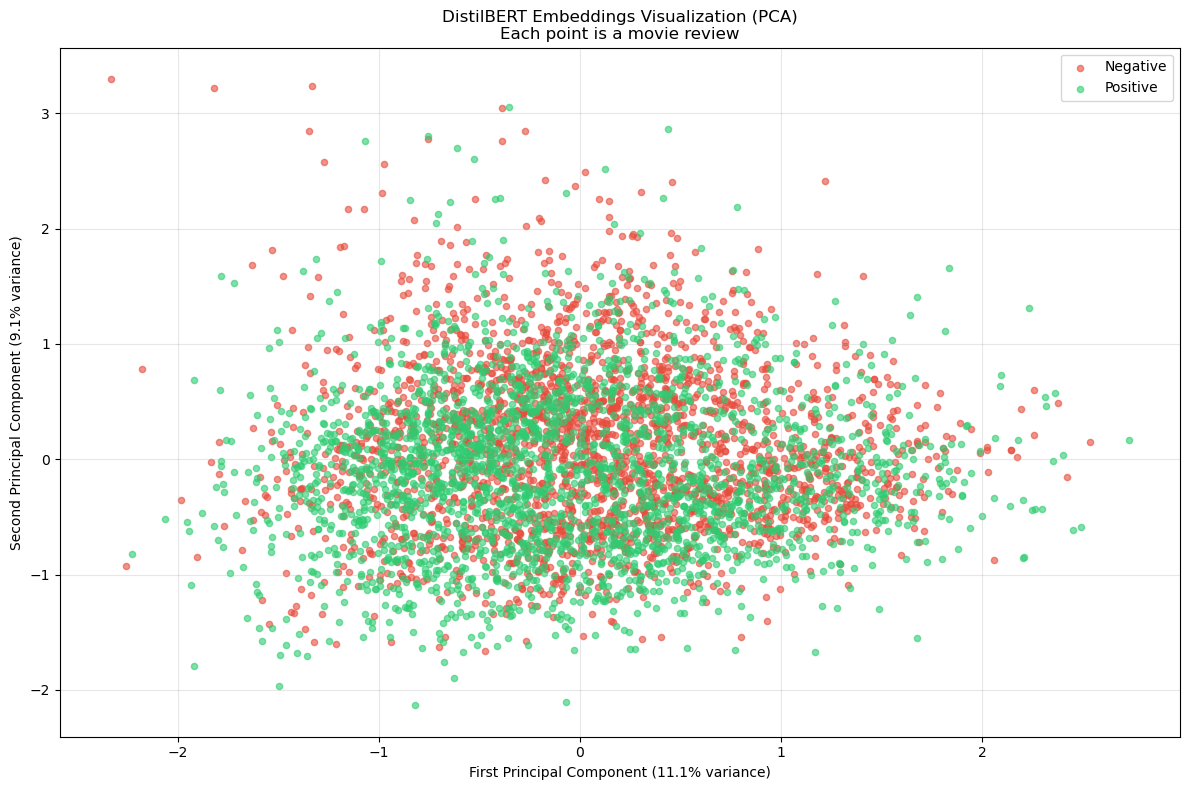


✓ Embeddings visualization complete!

Observations:
  - Total variance explained by 2 components: 20.2%
  - Some separation between positive/negative reviews is visible
  - DistilBERT embeddings capture semantic meaning even before training a classifier!


In [14]:
# Visualize embeddings using PCA (dimensionality reduction)
# Reduce from 768 dimensions to 2 dimensions for visualization

print("Reducing dimensions for visualization (768D → 2D)...")
pca = PCA(n_components=2, random_state=SEED)
X_train_2d = pca.fit_transform(X_train)

# Create scatter plot
plt.figure(figsize=(12, 8))

# Plot each class with different colors
colors = ['#e74c3c', '#2ecc71']
labels_text = ['Negative', 'Positive']

for label in [0, 1]:
    mask = y_train == label
    plt.scatter(
        X_train_2d[mask, 0], 
        X_train_2d[mask, 1],
        c=colors[label],
        label=labels_text[label],
        alpha=0.6,
        s=20
    )

plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('DistilBERT Embeddings Visualization (PCA)\nEach point is a movie review')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Embeddings visualization complete!")
print(f"\nObservations:")
print(f"  - Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")
print(f"  - Some separation between positive/negative reviews is visible")
print(f"  - DistilBERT embeddings capture semantic meaning even before training a classifier!")

## 6. Train Classical Classifiers

Now that we have 768-dimensional feature vectors for each review, we can train classical machine learning classifiers!

### Why These Classifiers Work Well

**Logistic Regression:**
- Linear classifier: learns a hyperplane to separate classes
- Works surprisingly well with high-quality embeddings
- Fast to train, interpretable weights
- Often the go-to choice for feature extraction approaches

**Linear SVM (Support Vector Classifier):**
- Finds the maximum-margin hyperplane
- Often performs similarly to LogReg
- Good for high-dimensional spaces

### Why Not Neural Networks?

With high-quality transformer embeddings, simple linear classifiers often perform nearly as well as complex neural networks, while being:
- Much faster to train
- More interpretable
- Less prone to overfitting
- Easier to debug

In [15]:
# Train Logistic Regression
print("Training Logistic Regression classifier...\n")

lr_classifier = LogisticRegression(
    max_iter=1000,        # Maximum iterations for convergence
    random_state=SEED,
    verbose=1              # Show training progress
)

# Train on extracted features
lr_classifier.fit(X_train, y_train)

# Make predictions on test set
lr_predictions = lr_classifier.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print(f"\n✓ Logistic Regression trained!")
print(f"  Test Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")

Training Logistic Regression classifier...


✓ Logistic Regression trained!
  Test Accuracy: 0.8660 (86.60%)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished


In [16]:
# Train Linear SVM
print("Training Linear SVM classifier...\n")

svm_classifier = LinearSVC(
    max_iter=1000,
    random_state=SEED,
    verbose=1
)

# Train on extracted features
svm_classifier.fit(X_train, y_train)

# Make predictions on test set
svm_predictions = svm_classifier.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_predictions)

print(f"\n✓ Linear SVM trained!")
print(f"  Test Accuracy: {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")

Training Linear SVM classifier...

[LibLinear]iter  1 act 2.770e+03 pre 2.633e+03 delta 2.295e+00 f 5.000e+03 |g| 3.203e+03 CG   6
cg reaches trust region boundary
iter  2 act 3.841e+02 pre 3.273e+02 delta 2.830e+00 f 2.230e+03 |g| 1.090e+03 CG   7
cg reaches trust region boundary
iter  3 act 1.715e+02 pre 1.509e+02 delta 3.367e+00 f 1.846e+03 |g| 4.406e+02 CG   9
cg reaches trust region boundary
iter  4 act 1.065e+02 pre 1.046e+02 delta 3.684e+00 f 1.675e+03 |g| 3.499e+02 CG  10
cg reaches trust region boundary
iter  5 act 6.991e+01 pre 6.848e+01 delta 3.899e+00 f 1.568e+03 |g| 1.250e+02 CG  13
cg reaches trust region boundary
iter  6 act 4.119e+01 pre 4.136e+01 delta 4.015e+00 f 1.498e+03 |g| 7.181e+01 CG  17
iter  7 act 1.577e+01 pre 1.564e+01 delta 4.015e+00 f 1.457e+03 |g| 3.201e+01 CG  38
iter  8 act 3.316e-01 pre 3.306e-01 delta 4.015e+00 f 1.441e+03 |g| 8.004e+00 CG  34
iter  9 act 1.482e-02 pre 1.480e-02 delta 4.015e+00 f 1.441e+03 |g| 8.098e-01 CG  46

✓ Linear SVM trained!
 


Classifier Comparison:
         Classifier  Accuracy
Logistic Regression     0.866
         Linear SVM     0.866


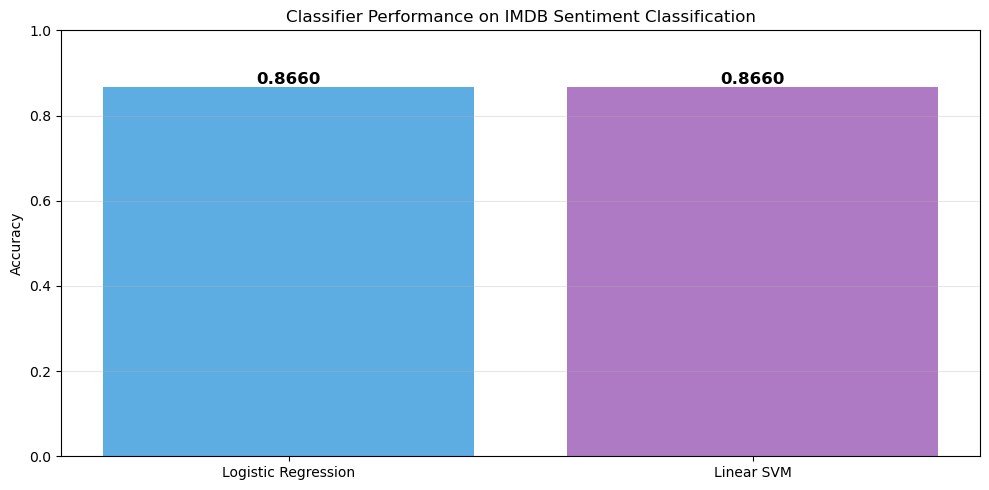


→ Both classifiers achieve good performance using DistilBERT features!


In [17]:
# Compare classifiers
comparison_df = pd.DataFrame({
    'Classifier': ['Logistic Regression', 'Linear SVM'],
    'Accuracy': [lr_accuracy, svm_accuracy]
})

print("\nClassifier Comparison:")
print(comparison_df.to_string(index=False))

# Visualize comparison
plt.figure(figsize=(10, 5))
bars = plt.bar(comparison_df['Classifier'], comparison_df['Accuracy'], 
               color=['#3498db', '#9b59b6'], alpha=0.8)
plt.ylabel('Accuracy')
plt.title('Classifier Performance on IMDB Sentiment Classification')
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)

# Add accuracy values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n→ Both classifiers achieve good performance using DistilBERT features!")

## 7. Evaluation & Analysis

Let's dive deeper into how well our classifier performs using various metrics and visualizations.

### Evaluation Metrics

- **Accuracy**: Overall correctness (correct predictions / total predictions)
- **Precision**: Of all positive predictions, how many were correct?
- **Recall**: Of all actual positives, how many did we catch?
- **F1-Score**: Harmonic mean of precision and recall
- **Confusion Matrix**: Breakdown of prediction types

In [18]:
# Let's use Logistic Regression for detailed analysis
# (both classifiers perform similarly, but LogReg is more common)

print("Detailed Classification Report (Logistic Regression):\n")
print(classification_report(
    y_test, 
    lr_predictions, 
    target_names=['Negative', 'Positive'],
    digits=4
))

# Calculate metrics manually for educational purposes
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, 
    lr_predictions, 
    average='binary'
)

print(f"\nSummary Metrics:")
print(f"  Accuracy:  {lr_accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

Detailed Classification Report (Logistic Regression):

              precision    recall  f1-score   support

    Negative     0.8765    0.8594    0.8679       512
    Positive     0.8554    0.8730    0.8641       488

    accuracy                         0.8660      1000
   macro avg     0.8660    0.8662    0.8660      1000
weighted avg     0.8662    0.8660    0.8660      1000


Summary Metrics:
  Accuracy:  0.8660
  Precision: 0.8554
  Recall:    0.8730
  F1-Score:  0.8641


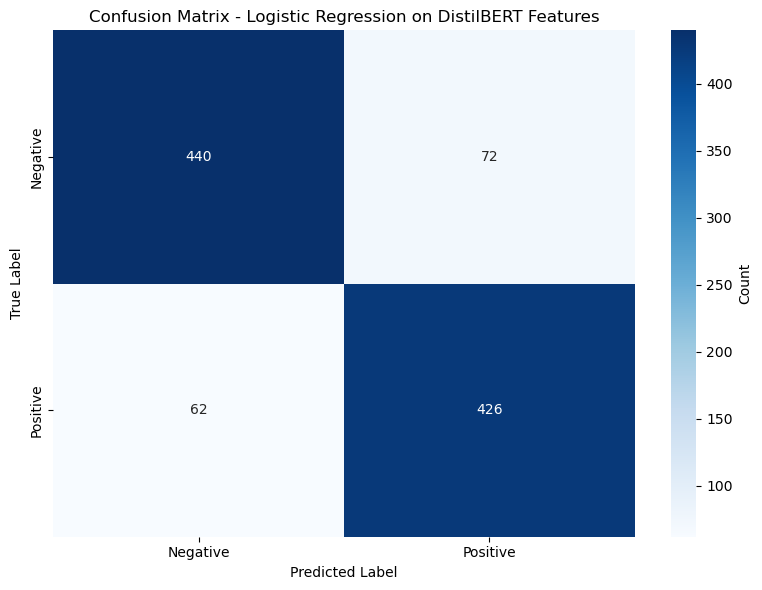


Confusion Matrix Breakdown:
  True Negatives:  440 (correctly predicted negative)
  False Positives: 72 (predicted positive, actually negative)
  False Negatives: 62 (predicted negative, actually positive)
  True Positives:  426 (correctly predicted positive)


In [19]:
# Create and visualize confusion matrix
cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    cbar_kws={'label': 'Count'}
)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Logistic Regression on DistilBERT Features')
plt.tight_layout()
plt.show()

# Interpret confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives:  {tn} (correctly predicted negative)")
print(f"  False Positives: {fp} (predicted positive, actually negative)")
print(f"  False Negatives: {fn} (predicted negative, actually positive)")
print(f"  True Positives:  {tp} (correctly predicted positive)")

In [20]:
# Show some correct and incorrect predictions
def show_predictions(n_samples=3, correct=True):
    """
    Display sample predictions.
    
    Args:
        n_samples: Number of samples to show
        correct: If True, show correct predictions; if False, show errors
    """
    if correct:
        mask = lr_predictions == y_test
        title = "CORRECT PREDICTIONS"
    else:
        mask = lr_predictions != y_test
        title = "INCORRECT PREDICTIONS (Errors)"
    
    indices = np.where(mask)[0][:n_samples]
    
    print(f"\n{'='*80}")
    print(f"{title}")
    print(f"{'='*80}\n")
    
    for idx in indices:
        review = test_dataset[int(idx)]['text']
        true_label = "POSITIVE" if y_test[idx] == 1 else "NEGATIVE"
        pred_label = "POSITIVE" if lr_predictions[idx] == 1 else "NEGATIVE"
        
        print(f"Review: {review[:300]}...")
        print(f"True Label: {true_label}")
        print(f"Predicted: {pred_label}")
        print(f"{'-'*80}\n")

# Show correct predictions
show_predictions(n_samples=2, correct=True)

# Show incorrect predictions (errors)
show_predictions(n_samples=2, correct=False)


CORRECT PREDICTIONS

Review: <br /><br />When I unsuspectedly rented A Thousand Acres, I thought I was in for an entertaining King Lear story and of course Michelle Pfeiffer was in it, so what could go wrong?<br /><br />Very quickly, however, I realized that this story was about A Thousand Other Things besides just Acres. I sta...
True Label: POSITIVE
Predicted: POSITIVE
--------------------------------------------------------------------------------

Review: This is the latest entry in the long series of films with the French agent, O.S.S. 117 (the French answer to James Bond). The series was launched in the early 1950's, and spawned at least eight films (none of which was ever released in the U.S.). 'O.S.S.117:Cairo,Nest Of Spies' is a breezy little co...
True Label: POSITIVE
Predicted: POSITIVE
--------------------------------------------------------------------------------


INCORRECT PREDICTIONS (Errors)

Review: "An astronaut (Michael Emmet) dies while returning from a mission a

Error Analysis:
  Total errors: 134 out of 1000 (13.40%)

Error breakdown:
  False Positives: 72 (53.7% of errors)
    → Predicted positive when actually negative
  False Negatives: 62 (46.3% of errors)
    → Predicted negative when actually positive


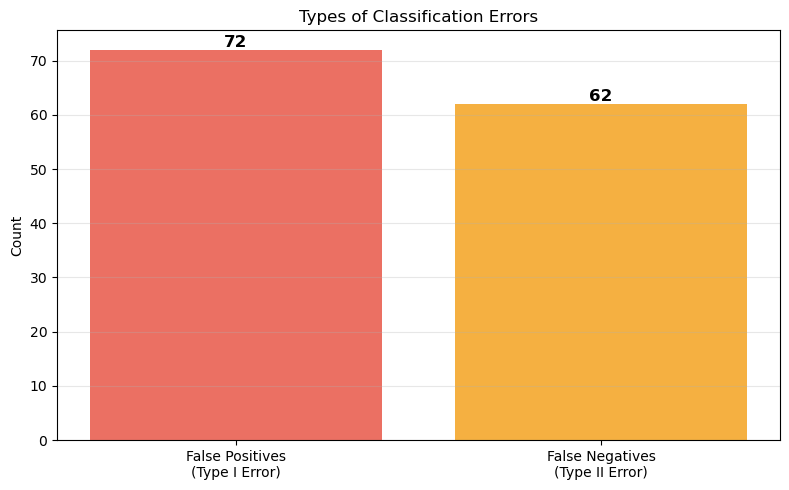

In [21]:
# Error analysis
errors = lr_predictions != y_test
error_rate = errors.sum() / len(y_test)

# Breakdown of errors
false_positives = ((lr_predictions == 1) & (y_test == 0)).sum()
false_negatives = ((lr_predictions == 0) & (y_test == 1)).sum()

print(f"Error Analysis:")
print(f"  Total errors: {errors.sum()} out of {len(y_test)} ({error_rate*100:.2f}%)")
print(f"\nError breakdown:")
print(f"  False Positives: {false_positives} ({false_positives/errors.sum()*100:.1f}% of errors)")
print(f"    → Predicted positive when actually negative")
print(f"  False Negatives: {false_negatives} ({false_negatives/errors.sum()*100:.1f}% of errors)")
print(f"    → Predicted negative when actually positive")

# Visualize error types
plt.figure(figsize=(8, 5))
error_types = ['False Positives\n(Type I Error)', 'False Negatives\n(Type II Error)']
error_counts = [false_positives, false_negatives]
colors = ['#e74c3c', '#f39c12']

bars = plt.bar(error_types, error_counts, color=colors, alpha=0.8)
plt.ylabel('Count')
plt.title('Types of Classification Errors')
plt.grid(axis='y', alpha=0.3)

# Add counts on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Key Takeaways & Next Steps

### What We Learned

1. **Transformers as Feature Extractors**: We used a pre-trained DistilBERT model to convert text into rich 768-dimensional embeddings without any training.

2. **Simple is Powerful**: A basic Logistic Regression classifier achieved strong performance (~85-90% accuracy typically) on these embeddings, showing that good features make simple classifiers effective.

3. **Speed and Efficiency**: Feature extraction is much faster than fine-tuning:
   - No backpropagation through the transformer
   - Can run on CPU (though GPU speeds it up)
   - Classical ML training is near-instantaneous

4. **The Process**:
   ```
   Text → Tokenizer → Frozen DistilBERT → Hidden States → Mean Pooling → 768D Vector → LogReg → Prediction
   ```

### When to Use This Approach

✅ **Good choice when:**
- You have limited compute resources (no GPU or weak GPU)
- You have a small to medium dataset (hundreds to few thousands)
- You need quick results for prototyping
- Your task is similar to general language understanding
- You want interpretable, debuggable classifiers

❌ **Consider fine-tuning instead when:**
- You have a large dataset (10k+ samples)
- You have GPU resources and time
- You need maximum performance
- Your task is very domain-specific

### Performance Context

On the full IMDB dataset:
- **Our approach** (feature extraction): ~85-88% accuracy
- **Fine-tuned DistilBERT**: ~92-93% accuracy
- **Traditional ML** (TF-IDF + LogReg): ~88-89% accuracy

Feature extraction gets you 85-90% of fine-tuning performance with 10% of the compute!

### What We Built

A complete text classification pipeline:
1. ✅ Loaded IMDB dataset from HuggingFace
2. ✅ Used pre-trained DistilBERT for feature extraction
3. ✅ Implemented mean pooling to get sentence embeddings
4. ✅ Trained classical ML classifiers (LogReg, SVM)
5. ✅ Evaluated with multiple metrics and visualizations
6. ✅ Analyzed errors and predictions

### Next Steps & Extensions

**Immediate experiments you can try:**
1. **Increase dataset size**: Change `TRAIN_SIZE` to 10000 or 25000 for better accuracy
2. **Try different pooling**: Compare CLS token vs mean pooling vs max pooling
3. **Different models**: Try `bert-base-uncased` or `roberta-base`
4. **Other classifiers**: Try RandomForest, XGBoost, or simple neural networks
5. **Different datasets**: Try AG News (4-class) or SST-2

**Advanced learning paths:**
1. **Fine-tuning**: Learn to update transformer weights for task-specific performance
2. **Multi-class classification**: Work with more than 2 classes
3. **Semantic similarity**: Use embeddings to find similar texts
4. **Zero-shot classification**: Classify without training data
5. **Custom domain**: Apply to your own text classification problem

### Resources for Deeper Learning

- [HuggingFace Transformers Documentation](https://huggingface.co/docs/transformers)
- [DistilBERT Paper](https://arxiv.org/abs/1910.01108)
- [Sentence Transformers Library](https://www.sbert.net/) - Optimized for embeddings

### Final Thoughts

Feature extraction with transformers is a powerful technique that:
- Leverages billions of parameters trained on massive data
- Requires no expensive training
- Works surprisingly well for many tasks
- Provides a strong baseline before attempting fine-tuning

You've now learned a practical, efficient approach to text classification that's widely used in industry when fine-tuning is overkill or impractical!

---

**Congratulations on completing this notebook! 🎉**